In [2]:
import nltk
import numpy
import matplotlib.pyplot
# import unidecode
# import langdetect
# import langid

In [3]:
nltk.download('popular')

nltk.download('punkt_tab')
nltk.download('maxent_ne_chunker_tab')

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets_json')
nltk.download('vader_lexicon')

nltk.download('brown')
nltk.download('reuters')
nltk.download('subjectivity')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

True

## Text Analysis

In [4]:
from nltk.tokenize import word_tokenize
from nltk.text import Text

our_string = ''' Our solar system consists of the Sun, eight recognized planets (Mercury, Venus, Earth, Mars, Jupiter, Saturn, Uranus, Neptune), dwarf planets (like Pluto), and numerous moons, asteroids, and comets, all orbiting the Sun. Formed 4.6 billion years ago, it is located in the Milky Way's Orion Arm. The inner, rocky planets (Mercury-Mars) are distinct from the outer gas/ice giants (Jupiter-Neptune).'''
tokens = word_tokenize(our_string)
tokens = [word.lower() for word in tokens]
tokens[:5]

['our', 'solar', 'system', 'consists', 'of']

In [6]:
text = Text(tokens)
text

<Text: our solar system consists of the sun ,...>

In [10]:
# Prints the index of the first occurrence of the word 'sun' in the Text object
print(text.index("sun"))

# Prints the total count of the word 'sun' in the Text object
print(text.count("sun"))

6
2


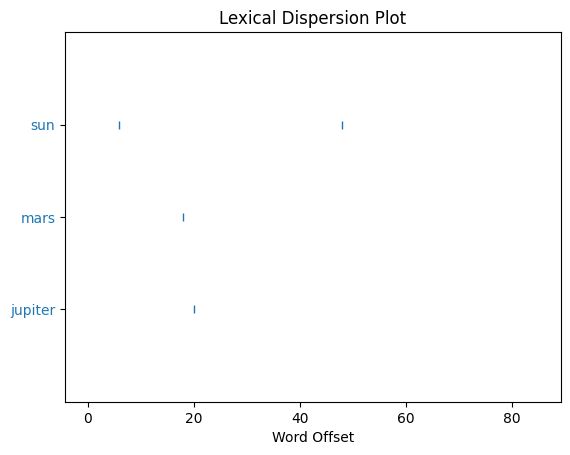

In [13]:
# A dispersion plot reveals patterns in word positions. Each stripe represents an instance of a word, and each row represents the entire text.
text.dispersion_plot(['sun', 'mars', 'jupiter'])

<Axes: xlabel='Samples', ylabel='Counts'>

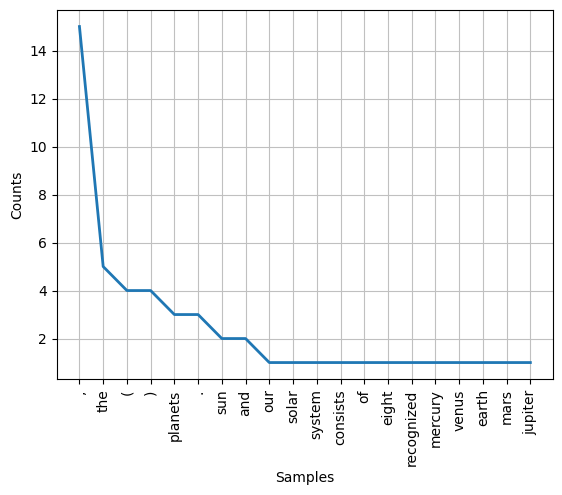

In [14]:
text.plot(20)

## Data Cleaning

In [17]:
import requests
from bs4 import BeautifulSoup

# 1. Target URL
url = "https://en.wikipedia.org/wiki/Solar_System"

# Add a User-Agent header to mimic a web browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# 2. Send GET request with headers
response = requests.get(url, headers=headers)
if response.status_code != 200:
    raise Exception(f"Failed to fetch page: {response.status_code}")

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Get Page Title
page_title = soup.find("h1", {"id": "firstHeading"}).get_text()
print("Page Title:", page_title)
print("=" * len(page_title))

# 5. Extract all paragraph texts
paragraphs = soup.find_all("p")
for i, p in enumerate(paragraphs, 1):
    text = p.get_text().strip()
    if text:  # skip empty paragraphs
      print(text)
        # print(f"\n--- Paragraph {i} ---\n{text}")

Page Title: Solar System
The Solar System is the gravitationally bound system of the Sun and the masses that orbit it, most prominently its eight planets, of which Earth is one. The system formed about 4.6 billion years ago when a dense region of a molecular cloud collapsed, creating the Sun and a protoplanetary disc from which the orbiting bodies assembled.
The Sun accounts for 99.86% of the Solar System's total mass. Inside the Sun's core, hydrogen is fused into helium, releasing energy that is emitted through the Sun's photosphere. This creates the heliosphere and a decreasing temperature gradient across the Solar System.
The next most massive objects of the system are the eight planets, which by definition dominate the orbits they occupy. Closest to the Sun in order of increasing distance are the terrestrial planets – Mercury, Venus, Earth and Mars. These are the planets of the inner Solar System. Earth and Mars are the only planets that orbit within the Sun's habitable zone, in wh

In [18]:
text

'Solar System\xa0→ Local Interstellar Cloud\xa0→ Local Bubble\xa0→ Gould Belt\xa0→ Orion Arm\xa0→ Milky Way\xa0→ Milky Way subgroup\xa0→ Local Group → Local Sheet → Local Volume → Virgo Supercluster → Laniakea Supercluster\xa0→ Pisces–Cetus Supercluster Complex\xa0→ Local Hole\xa0→ Observable universe\xa0→ UniverseEach arrow (→) may be read as "within" or "part of".'

In [19]:
import re
import string

def clean_text1(text):
    '''Make text lowercase, remove text in square brackets, remove punctuation and remove words containing numbers.'''
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

cleaned_text1 = clean_text1(text)
cleaned_text1

'solar system\xa0→ local interstellar cloud\xa0→ local bubble\xa0→ gould belt\xa0→ orion arm\xa0→ milky way\xa0→ milky way subgroup\xa0→ local group → local sheet → local volume → virgo supercluster → laniakea supercluster\xa0→ pisces–cetus supercluster complex\xa0→ local hole\xa0→ observable universe\xa0→ universeeach arrow → may be read as within or part of'

In [20]:
def clean_text2(text):
    '''Get rid of some additional punctuation and non-sensical text that was missed the first time around.'''
    text = re.sub('[‘’“”…]', '', text)
    text = re.sub('\n', '', text)
    return text

cleaned_text2 = clean_text2(text)
cleaned_text2

'Solar System\xa0→ Local Interstellar Cloud\xa0→ Local Bubble\xa0→ Gould Belt\xa0→ Orion Arm\xa0→ Milky Way\xa0→ Milky Way subgroup\xa0→ Local Group → Local Sheet → Local Volume → Virgo Supercluster → Laniakea Supercluster\xa0→ Pisces–Cetus Supercluster Complex\xa0→ Local Hole\xa0→ Observable universe\xa0→ UniverseEach arrow (→) may be read as "within" or "part of".'

## Ngram model

Tokenizes text

Creates padded character n-grams

Generates 1–4 grams

Counts frequencies

Groups by n

Displays top features

In [31]:
mystring = "Our solar system consists of the Sun, eight recognized planets (Mercury, Venus, Earth, Mars, Jupiter, Saturn, Uranus, Neptune), dwarf planets (like Pluto), and numerous moons, asteroids, and comets, all orbiting the Sun."
mystring = mystring.lower()

# Tokenize
from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer("[a-zA-Z'’`éèî]+")
mystring_tokenized = tokenizer.tokenize(mystring)

# Generate character 4-grams
from nltk.util import ngrams

generated_4grams = []

for word in mystring_tokenized:
    generated_4grams.append(
        list(
            ngrams(
                word,
                4,
                pad_left=True,
                pad_right=True,
                left_pad_symbol="_",
                right_pad_symbol="_"
            )
        )
    )

# Flatten
ng_list_4grams = [word for sublist in generated_4grams for word in sublist]

# Join characters
ng_list_4grams = [''.join(val) for val in ng_list_4grams]

# Count frequency (4-grams)
from collections import Counter

freq_4grams = Counter(ng_list_4grams)

# Top 20 most frequent
print("Top 20 4-grams:")
print(freq_4grams.most_common(20))



Top 20 4-grams:
[('s___', 10), ('___s', 5), ('ts__', 4), ('e___', 4), ('___a', 4), ('___o', 3), ('r___', 3), ('n___', 3), ('d___', 3), ('___p', 3), ('__pl', 3), ('ets_', 3), ('___m', 3), ('us__', 3), ('___c', 2), ('__co', 2), ('f___', 2), ('___t', 2), ('__th', 2), ('_the', 2)]


In [32]:

# MULTI-N GRAM (1–4) EXTRACTION
from nltk import everygrams

mystring_clean = ' '.join(mystring_tokenized)

def ngram_extractor(sent, max_n=4):
    return [
        ''.join(ng)
        for ng in everygrams(sent.replace(' ', '_ _'), 1, max_n)
        if ' ' not in ng and '\n' not in ng and ng != ('_',)
    ]

all_ngrams = ngram_extractor(mystring_clean, 4)

# Count all n-grams (1 to 4)
freq_all = Counter(all_ngrams)

print("\nTop 20 n-grams (1–4):")
print(freq_all.most_common(20))



Top 20 n-grams (1–4):
[('s', 19), ('e', 18), ('n', 16), ('t', 15), ('r', 14), ('u', 13), ('o', 12), ('a', 12), ('s_', 10), ('i', 8), ('l', 7), ('m', 6), ('_s', 5), ('d', 5), ('p', 5), ('an', 5), ('ur', 4), ('ar', 4), ('c', 4), ('ts', 4)]


In [33]:
#  Group by length
from collections import defaultdict

ngrams_by_length = defaultdict(list)

for ng, freq in freq_all.items():
    ngrams_by_length[len(ng)].append((ng, freq))

for n in range(1, 5):
    sorted_list = sorted(ngrams_by_length[n], key=lambda x: x[1], reverse=True)
    print(f"\nTop {n}-grams:")
    print(sorted_list[:10])


Top 1-grams:
[('s', 19), ('e', 18), ('n', 16), ('t', 15), ('r', 14), ('u', 13), ('o', 12), ('a', 12), ('i', 8), ('l', 7)]

Top 2-grams:
[('s_', 10), ('_s', 5), ('an', 5), ('ur', 4), ('ar', 4), ('ts', 4), ('e_', 4), ('ne', 4), ('er', 4), ('_a', 4)]

Top 3-grams:
[('ts_', 4), ('_pl', 3), ('ets', 3), ('us_', 3), ('ste', 2), ('_co', 2), ('ons', 2), ('_th', 2), ('the', 2), ('he_', 2)]

Top 4-grams:
[('ets_', 3), ('_the', 2), ('the_', 2), ('_sun', 2), ('_pla', 2), ('plan', 2), ('lane', 2), ('anet', 2), ('nets', 2), ('nus_', 2)]


In [35]:
# Generate word-level n-grams
from nltk.util import ngrams
from collections import Counter

def generate_word_ngrams(tokens, n):
    return list(ngrams(tokens, n))


# Example: Bigrams
bigrams = generate_word_ngrams(tokens, 2)
print("\nBigrams:\n", bigrams[:10])

# Frequency Counts
def ngram_frequency(tokens, n):
    ng = generate_word_ngrams(tokens, n)
    return Counter(ng)

freq_unigram = ngram_frequency(tokens, 1)
freq_bigram = ngram_frequency(tokens, 2)
freq_trigram = ngram_frequency(tokens, 3)
freq_fourgram = ngram_frequency(tokens, 4)

print("\nTop 10 Unigrams:")
print(freq_unigram.most_common(10))

print("\nTop 10 Bigrams:")
print(freq_bigram.most_common(10))

print("\nTop 10 Trigrams:")
print(freq_trigram.most_common(10))

print("\nTop 10 4-grams:")
print(freq_fourgram.most_common(10))


Bigrams:
 [('our', 'solar'), ('solar', 'system'), ('system', 'consists'), ('consists', 'of'), ('of', 'the'), ('the', 'sun'), ('sun', ','), (',', 'eight'), ('eight', 'recognized'), ('recognized', 'planets')]

Top 10 Unigrams:
[((',',), 15), (('the',), 5), (('(',), 4), ((')',), 4), (('planets',), 3), (('.',), 3), (('sun',), 2), (('and',), 2), (('our',), 1), (('solar',), 1)]

Top 10 Bigrams:
[(('planets', '('), 3), (('the', 'sun'), 2), ((')', ','), 2), ((',', 'and'), 2), (('our', 'solar'), 1), (('solar', 'system'), 1), (('system', 'consists'), 1), (('consists', 'of'), 1), (('of', 'the'), 1), (('sun', ','), 1)]

Top 10 Trigrams:
[(('our', 'solar', 'system'), 1), (('solar', 'system', 'consists'), 1), (('system', 'consists', 'of'), 1), (('consists', 'of', 'the'), 1), (('of', 'the', 'sun'), 1), (('the', 'sun', ','), 1), (('sun', ',', 'eight'), 1), ((',', 'eight', 'recognized'), 1), (('eight', 'recognized', 'planets'), 1), (('recognized', 'planets', '('), 1)]

Top 10 4-grams:
[(('our', 'solar

In [36]:
from nltk.util import everygrams

all_ngrams = list(everygrams(tokens, min_len=1, max_len=4))
freq_all = Counter(all_ngrams)

print("\nTop 15 (1–4 grams combined):")
print(freq_all.most_common(15))


Top 15 (1–4 grams combined):
[((',',), 15), (('the',), 5), (('(',), 4), ((')',), 4), (('planets',), 3), (('planets', '('), 3), (('.',), 3), (('the', 'sun'), 2), (('sun',), 2), ((')', ','), 2), ((',', 'and'), 2), (('and',), 2), (('our',), 1), (('our', 'solar'), 1), (('our', 'solar', 'system'), 1)]


Language identfier

In [42]:
import math
from collections import Counter
from nltk.util import ngrams
from nltk.tokenize import RegexpTokenizer

# Training Data (Small Example)
english_text = """
The solar system consists of the Sun and eight planets.
Earth revolves around the Sun.
The planets orbit in space.
"""

french_text = """
Le système solaire se compose du Soleil et de huit planètes.
La Terre tourne autour du Soleil.
Les planètes orbitent dans l'espace.
"""

spanish_text = """
El sistema solar consiste en el Sol y ocho planetas.
La Tierra gira alrededor del Sol.
Los planetas orbitan en el espacio.
"""

# Tokenizer
tokenizer = RegexpTokenizer(r"\w+")

def tokenize(text):
    return tokenizer.tokenize(text.lower())

# Build Bigram Model
def build_bigram_model(text):
    tokens = tokenize(text)
    bigrams = list(ngrams(tokens, 2))
    return Counter(bigrams), len(tokens)


eng_model, eng_total = build_bigram_model(english_text)
fr_model, fr_total = build_bigram_model(french_text)
es_model, es_total = build_bigram_model(spanish_text)

vocab_size = len(set(list(eng_model.keys()) +
                     list(fr_model.keys()) +
                     list(es_model.keys())))


In [43]:


# -----------------------------------
# 4. Score Function (Laplace Smoothing)
# -----------------------------------

def score(text, model, total_tokens):
    tokens = tokenize(text)
    bigrams = list(ngrams(tokens, 2))

    log_prob = 0

    for bg in bigrams:
        count = model.get(bg, 0)
        probability = (count + 1) / (total_tokens + vocab_size)
        log_prob += math.log(probability)

    return log_prob


# -----------------------------------
# 5. Language Prediction
# -----------------------------------

def predict_language(text):
    scores = {
        "English": score(text, eng_model, eng_total),
        "French": score(text, fr_model, fr_total),
        "Spanish": score(text, es_model, es_total)
    }

    return max(scores, key=scores.get), scores



In [44]:

# -----------------------------------
# 6. Test
# -----------------------------------

test_sentence = "The planets revolve around the sun"

prediction, scores = predict_language(test_sentence)

print("Test Sentence:", test_sentence)
print("Scores:", scores)
print("Predicted Language:", prediction)

Test Sentence: The planets revolve around the sun
Scores: {'English': -19.362332612547107, 'French': -22.033596236321266, 'Spanish': -21.972245773362197}
Predicted Language: English


## stop words

In [39]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
text = "This is a sample sentence showing stop words removal."
stop_words = set(stopwords.words('english'))
word_tokens = word_tokenize(text)

filtered_text = [word for word in word_tokens if word.lower() not in stop_words]

print("Original:", text)
print("Filtered:", " ".join(filtered_text))
# Output: Filtered: sample sentence showing stop words removal .


Original: This is a sample sentence showing stop words removal.
Filtered: sample sentence showing stop words removal .


counting stop words

In [41]:
# 2. Define the sample text
text = "The quick brown fox jumps over the lazy dog. The dog was not amused."

# 3. Tokenize and normalize text (convert to lowercase)
words = word_tokenize(text.lower())

# 4. Load English stop words
stop_words = set(stopwords.words('english'))

# 5. Filter out stop words
filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

# 6. Count the frequencies of remaining words
word_counts = Counter(filtered_words)

# 7. Print results
print("Original Tokens:", words)
print("Filtered Tokens:", filtered_words)
print("Word Frequencies:", word_counts)

Original Tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.', 'the', 'dog', 'was', 'not', 'amused', '.']
Filtered Tokens: ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog', 'dog', 'amused']
Word Frequencies: Counter({'dog': 2, 'quick': 1, 'brown': 1, 'fox': 1, 'jumps': 1, 'lazy': 1, 'amused': 1})
